# Plot EHRformer embeddings

In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import numpy as np

import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import common_data
import common_plots

In [3]:
common_plots.setup_plotting()

In [4]:
%config InlineBackend.figure_format = "retina"

In [5]:
PATOGENE_LABELS_PATH = common_data.CLINICAL_LABELS

In [6]:
pd.options.display.max_columns = 300

In [7]:
labels_df = pd.read_csv(PATOGENE_LABELS_PATH, index_col=0)

In [ ]:
embeddings = pd.read_csv('04_embeddings_umap.csv', index_col=0)

In [9]:
labels_df = labels_df.merge(embeddings, left_index=True, right_index=True)

In [10]:
labels_df['Discharge_disposition'] = pd.Categorical(
    labels_df['Discharge_disposition'],
    categories=['Home', 'Rehab', 'SNF', 'LTACH', 'Hospice', 'Died']
)

In [11]:
ehr_data = pd.read_csv(common_data.CLINICAL, index_col=0)

In [12]:
plot_df = labels_df.merge(ehr_data, left_index=True, right_index=True, suffixes=('', '_ehr'))

In [13]:
plot_df.rename(columns={'umap1': 'umap_1', 'umap2': 'umap_2'}, inplace=True)

In [14]:
plot_df['day_of_hospitalization_log'] = np.log(plot_df['day_of_hospitalization'])

In [15]:
AXES_POS = (0.4, 0.18, 0.2, 0.02)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


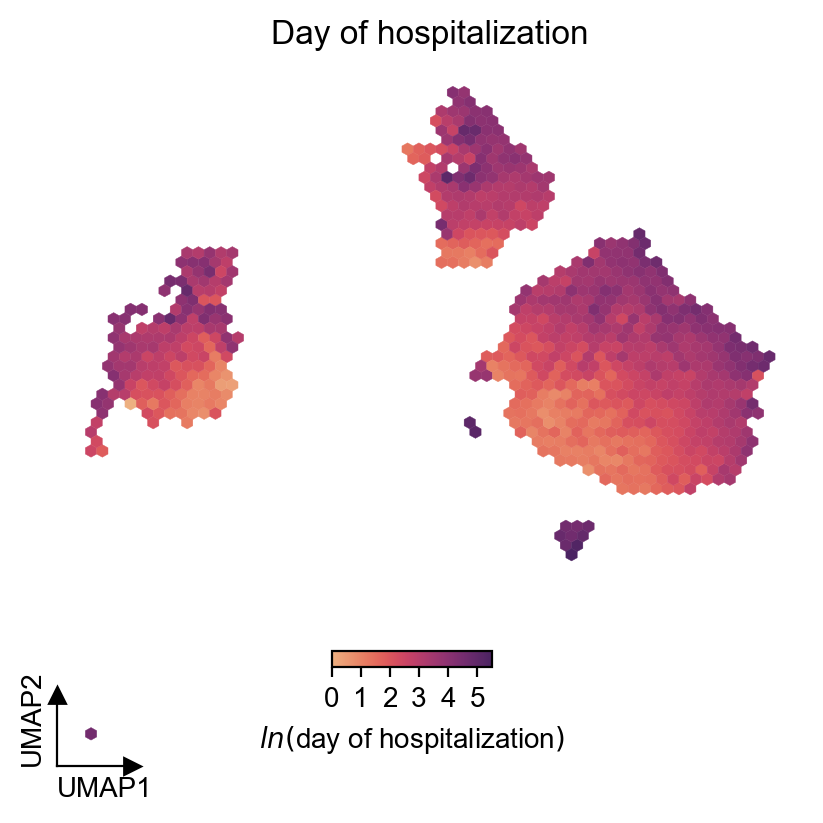

In [16]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['day_of_hospitalization_log'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(plot_df.day_of_hospitalization_log.min(), plot_df.day_of_hospitalization_log.max())
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='$ln($day of hospitalization$)$',
    orientation='horizontal',
    ticks=[0, 1, 2, 3, 4, 5]
)
ax.collections[0].set_rasterized(True)
ax.set_title('Day of hospitalization')
fig.savefig(f'00_plots/ehrformer_emb_ln_day.pdf', dpi=300)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'vap_onset')

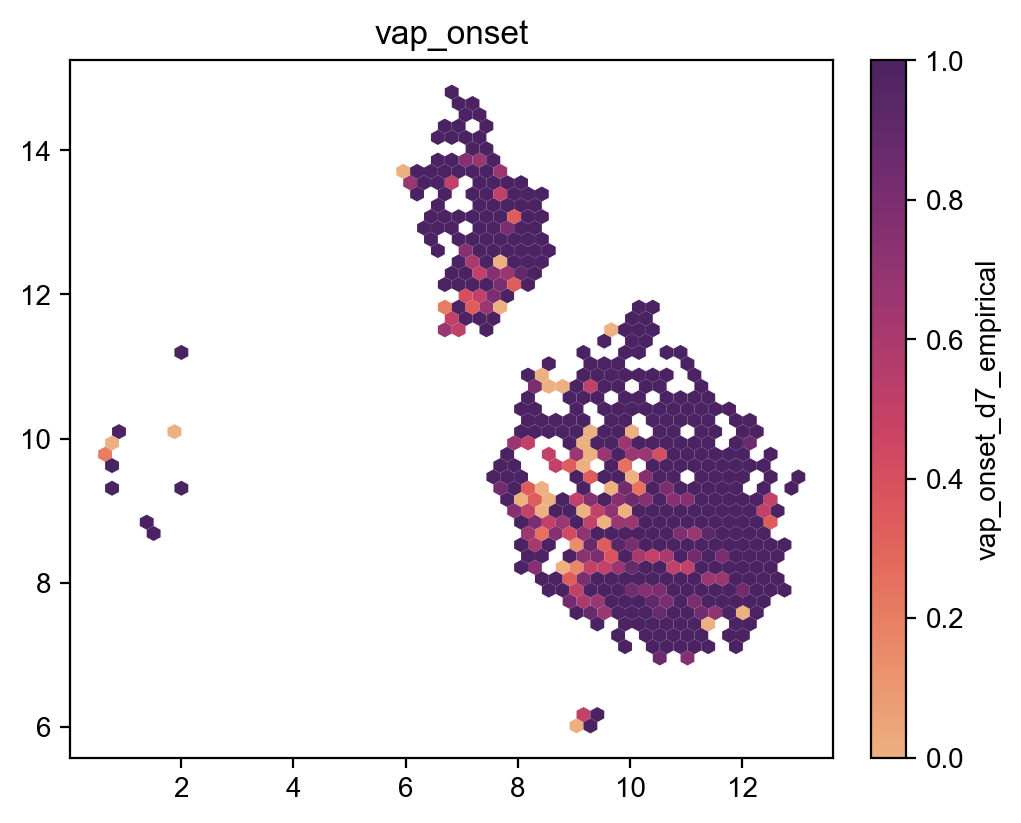

In [ ]:
plot_df['vap_onset_color'] = plot_df.vap_onset_d7_empirical.replace({-1: np.nan})
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df.vap_onset_color,
    gridsize=50,
    cmap='flare',
    ec='none',
)

norm = plt.Normalize(plot_df.vap_onset_color.min(), plot_df.vap_onset_color.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
sm.set_array([])

# Remove the legend and add a colorbar
# ax.get_legend().remove()
ax.figure.colorbar(sm, ax=ax, label='vap_onset_d7_empirical')

ax.set_title('vap_onset')

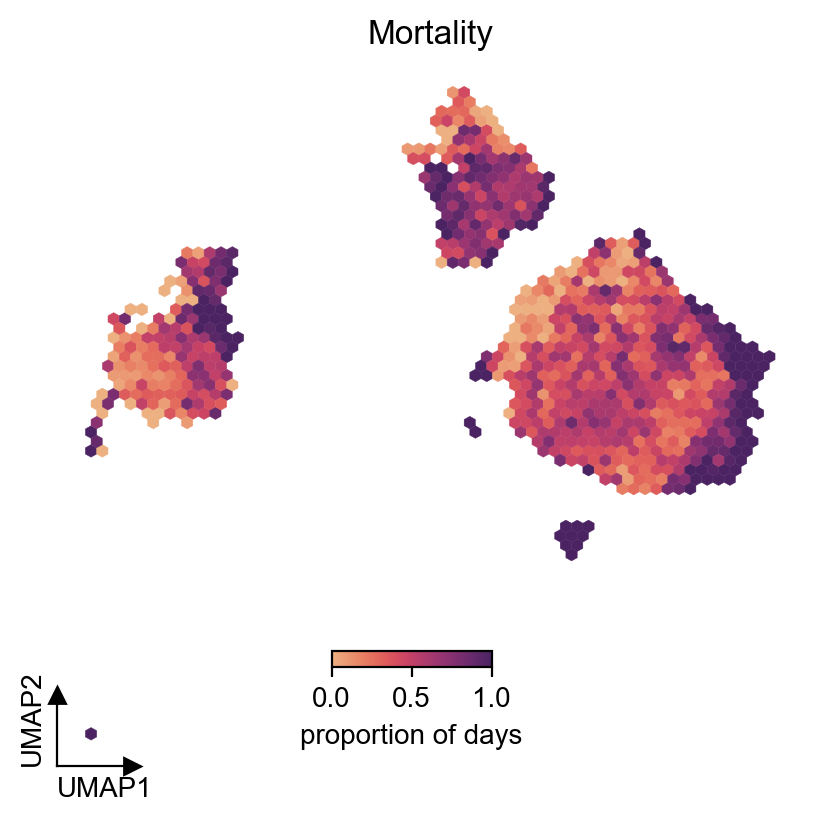

In [20]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['Binary_outcome'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='proportion of days',
    orientation='horizontal',
    ticks=[0, 0.5, 1]
)
ax.collections[0].set_rasterized(True)
ax.set_title('Mortality')
# cax.set_xticks([5, 15], minor=True)
fig.savefig(f'00_plots/ehrformer_emb_mortality.pdf', dpi=300)
# plt.show()

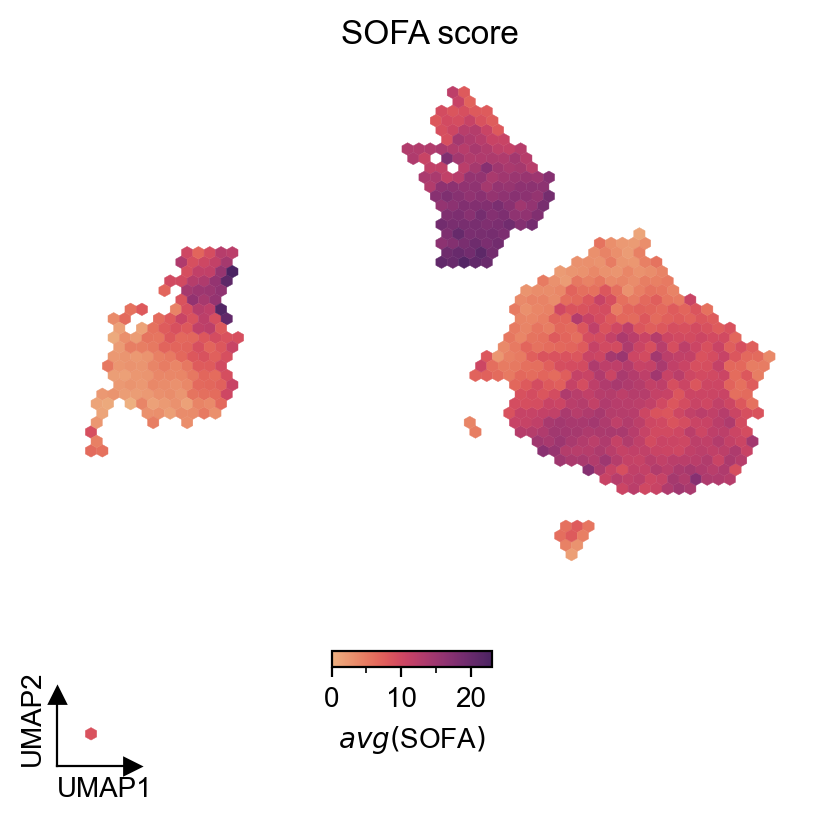

In [21]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['SOFA_score'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(plot_df.SOFA_score.min(), plot_df.SOFA_score.max())
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='$avg($SOFA$)$',
    orientation='horizontal',
    ticks=[0, 10, 20]
)
ax.collections[0].set_rasterized(True)
ax.set_title('SOFA score')
cax.set_xticks([5, 15], minor=True)
fig.savefig(f'00_plots/ehrformer_emb_sofa.pdf', dpi=300)
# plt.show()

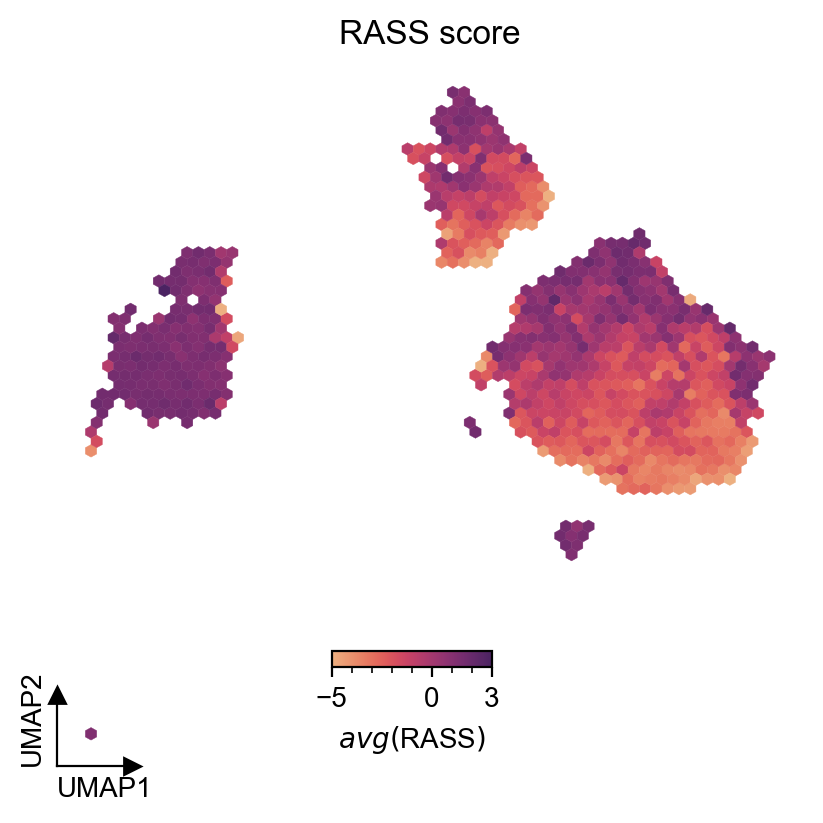

In [22]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['RASS_score'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(plot_df.RASS_score.min(), plot_df.RASS_score.max())
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='$avg($RASS$)$',
    orientation='horizontal',
    ticks=[-5, 0, 3]
)
ax.collections[0].set_rasterized(True)
ax.set_title('RASS score')
cax.set_xticks([-4, -3, -2, -1, 1, 2], minor=True)
fig.savefig(f'00_plots/ehrformer_emb_rass.pdf', dpi=300)
# plt.show()

In [23]:
plot_df.perturbation_groups_2.unique()

array(['discard', 'Gram-*', 'Gram+', 'Gram-*; Gram+', 'NPC',
       'Pseudomonas aeruginosa', 'Early SARS-CoV-2', 'Late SARS-CoV-2',
       'Late SARS-CoV-2; Gram+', 'Early SARS-CoV-2; Gram+',
       'Pseudomonas aeruginosa; SARS-CoV-2'], dtype=object)

In [24]:
plot_df['perturbation_groups_2'] = pd.Categorical(
    plot_df['perturbation_groups_2'],
    categories=[
        'discard', 'NPC', 'Early SARS-CoV-2', 'Late SARS-CoV-2',
        'Pseudomonas aeruginosa', 'Gram-*', 'Gram+', 'Gram-*; Gram+',
        'Early SARS-CoV-2; Gram+', 'Late SARS-CoV-2; Gram+',
        'Pseudomonas aeruginosa; SARS-CoV-2',
    ]
)

In [25]:
pathogen_pretty_names = {
    'NPC': 'NPC',
    'Early SARS-CoV-2': 'Early SARS-CoV-2',
    'Late SARS-CoV-2':'Late SARS-CoV-2',
    'Pseudomonas aeruginosa': 'Pseudomonas',
    'Gram-*': 'Other Gram–',
    'Gram+': 'Gram+',
    'Gram-*; Gram+': 'Other Gram–; Gram+',
    'Early SARS-CoV-2; Gram+': 'Early SARS-CoV-2; Gram+',
    'Late SARS-CoV-2; Gram+': 'Late SARS-CoV-2; Gram+',
    'Pseudomonas aeruginosa; SARS-CoV-2': 'SARS-CoV-2; Pseudomonas',
}

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


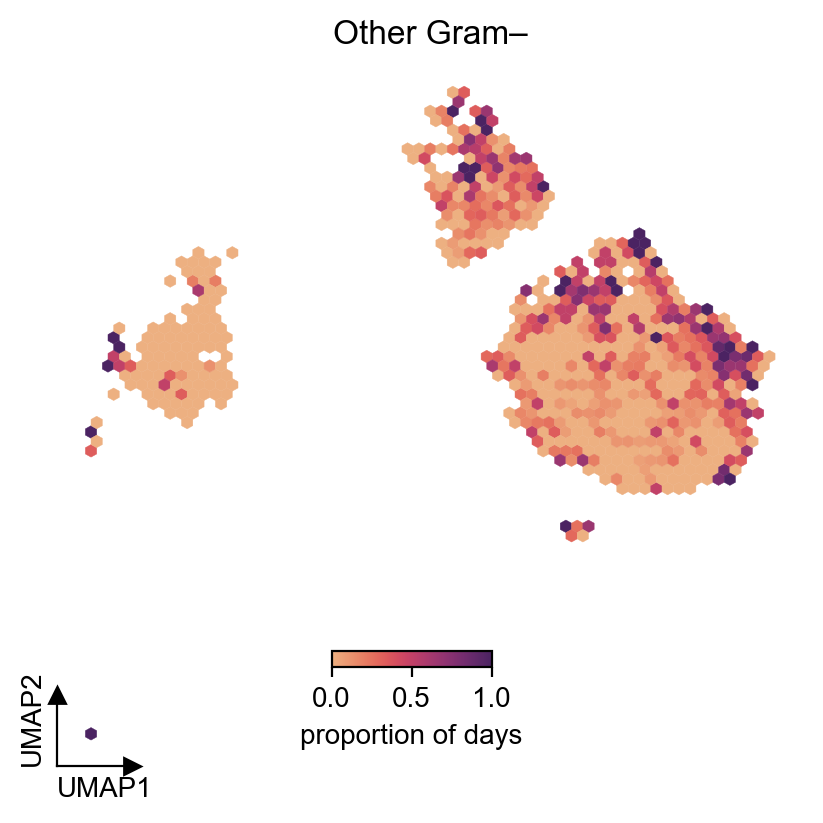

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


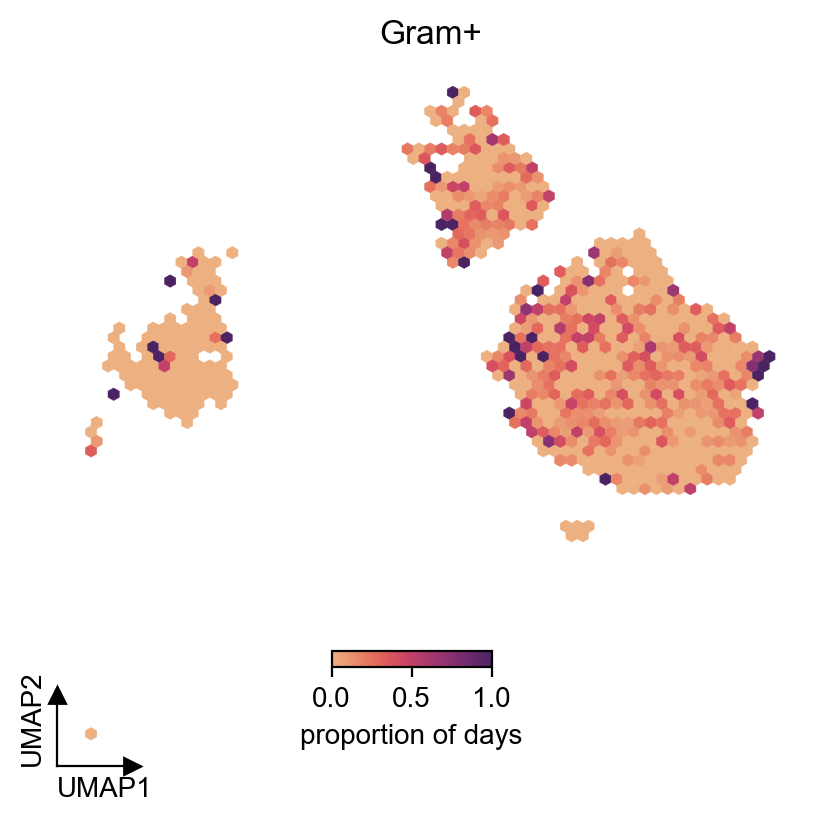

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


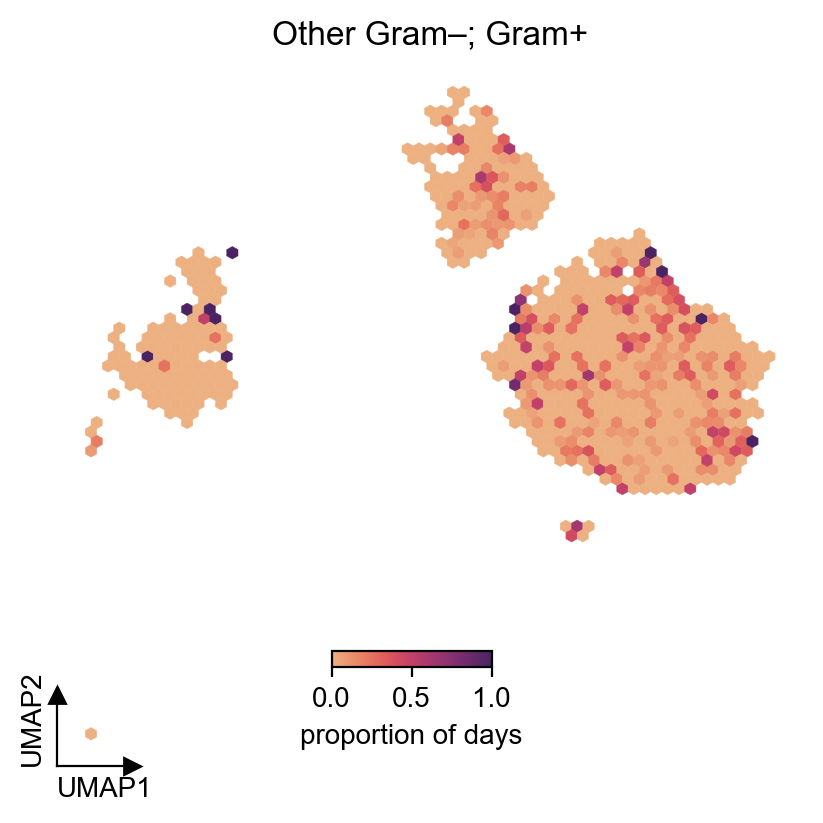

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


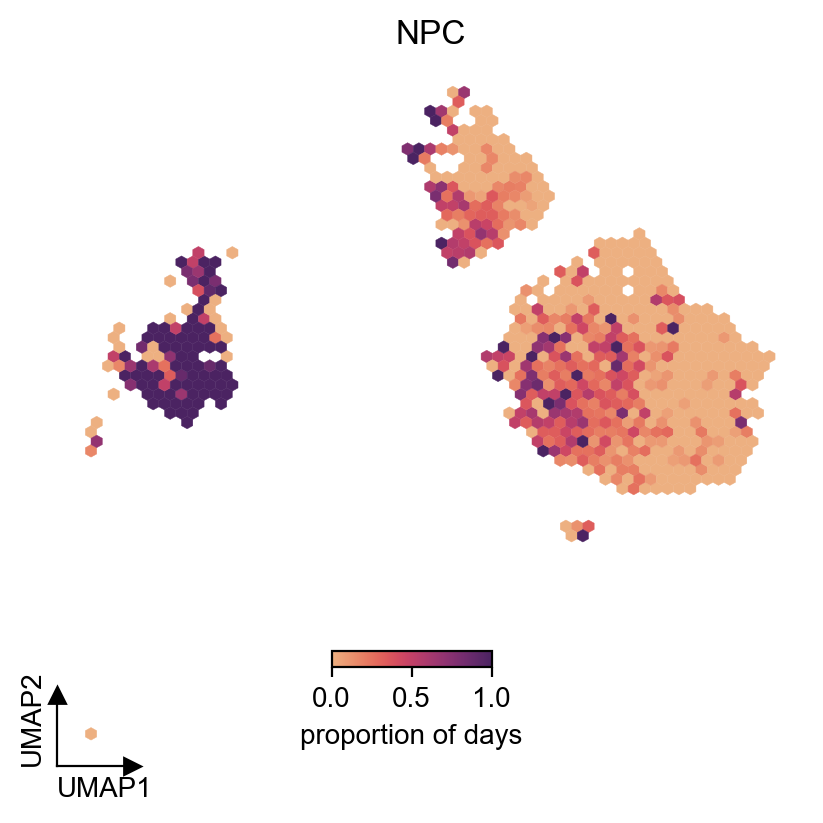

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


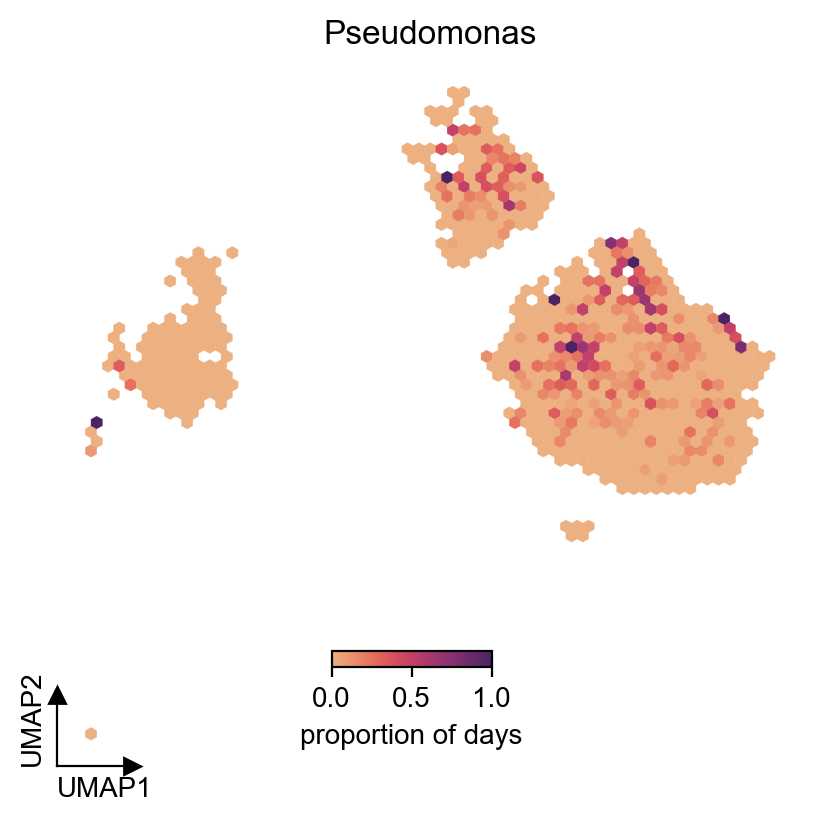

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


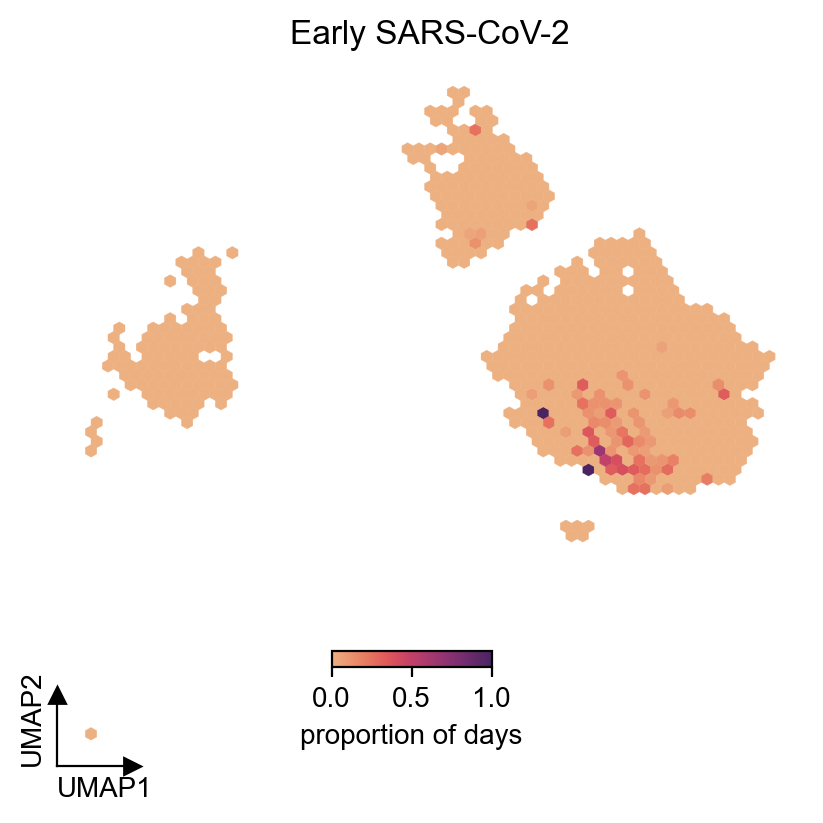

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


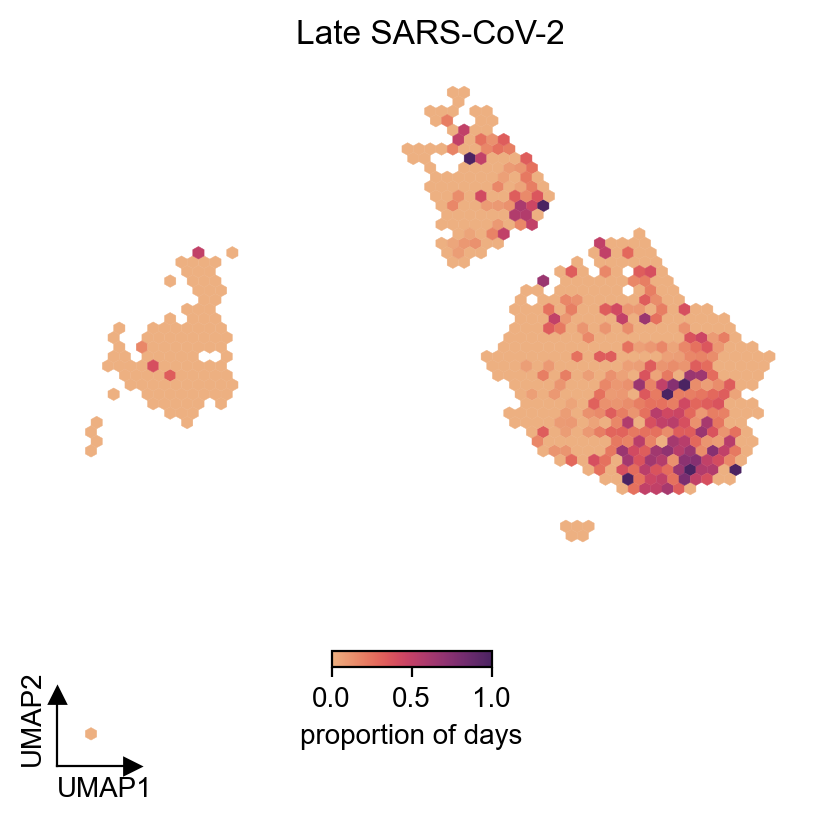

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


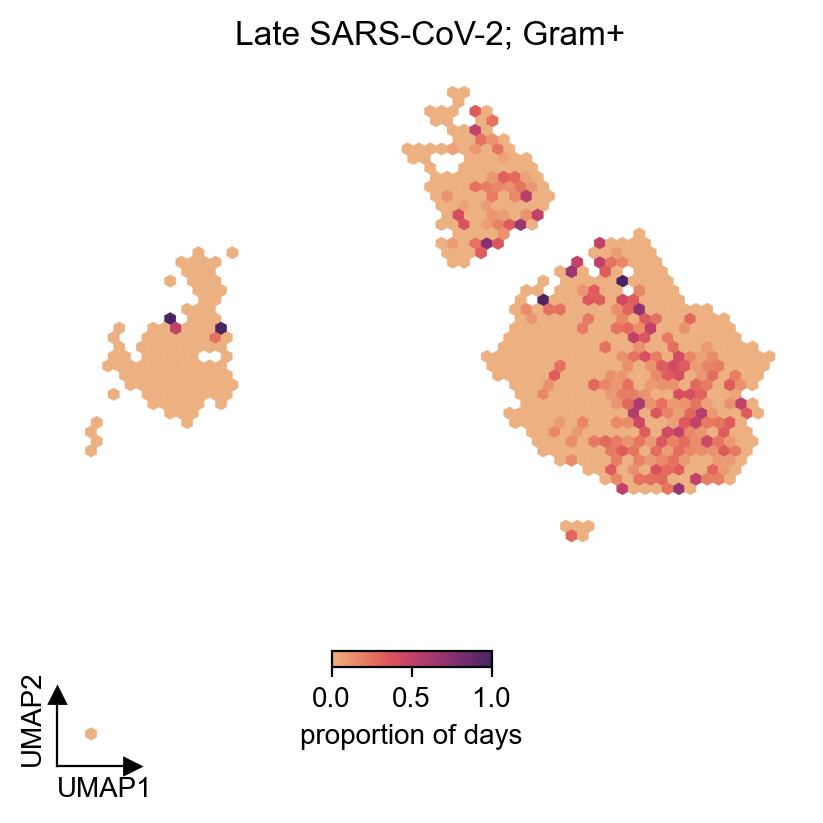

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


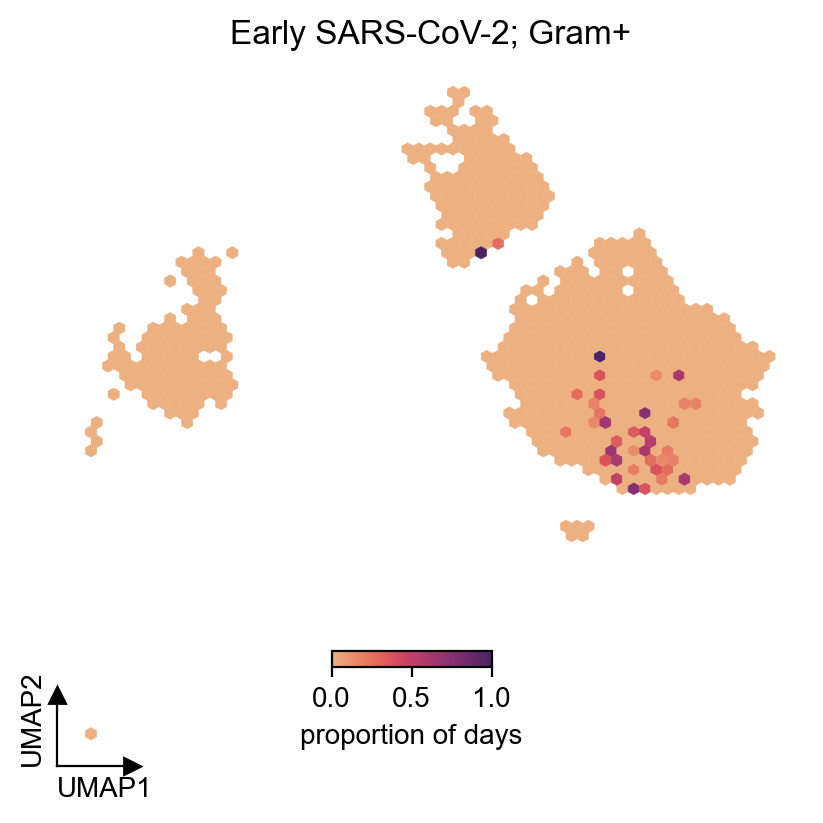

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


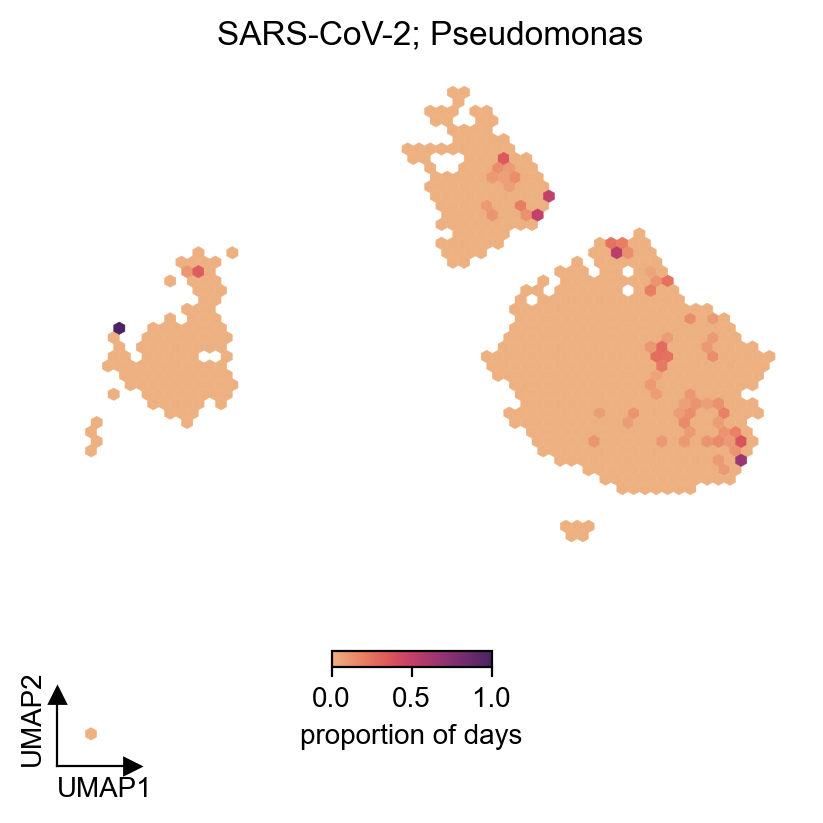

In [26]:
for pathogen in plot_df.perturbation_groups_2.unique():
    if pathogen == 'discard':
        continue
    fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
    plot_df_2 = plot_df.loc[plot_df.perturbation_groups_2.ne('discard')].copy()
    feature = f'is_{pathogen}'
    plot_df_2[feature] = plot_df_2.perturbation_groups_2.eq(pathogen).astype(int)
    ax.hexbin(
        x=plot_df_2.umap_1,
        y=plot_df_2.umap_2,
        C=plot_df_2[feature],
        gridsize=60,
        cmap='flare',
        # ec='none',
        linewidths=0.15
    )
    shrink_by = 0.1
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
    ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

    b = ax.spines["bottom"]
    b.set_bounds(xlim[0], xbound)
    ax.set_xlabel('UMAP1', x=0, ha="left")
    ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

    b = ax.spines["left"]
    b.set_bounds(ylim[0], ybound)
    ax.set_ylabel('UMAP2', y=0, ha="left")
    ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

    norm = plt.Normalize(0, 1)
    sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
    sm.set_array([])

    cax = fig.add_axes(AXES_POS)

    ax.figure.colorbar(
        sm,
        cax=cax,
        label=f'proportion of days',
        orientation='horizontal',
        ticks=[0, 0.5, 1]
    )
    ax.collections[0].set_rasterized(True)
    ax.set_title(pathogen_pretty_names[pathogen])
    fig.savefig(f'00_plots/ehrformer_emb_{pathogen}.pdf', dpi=300)
    plt.show()

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'is_episode_cured')

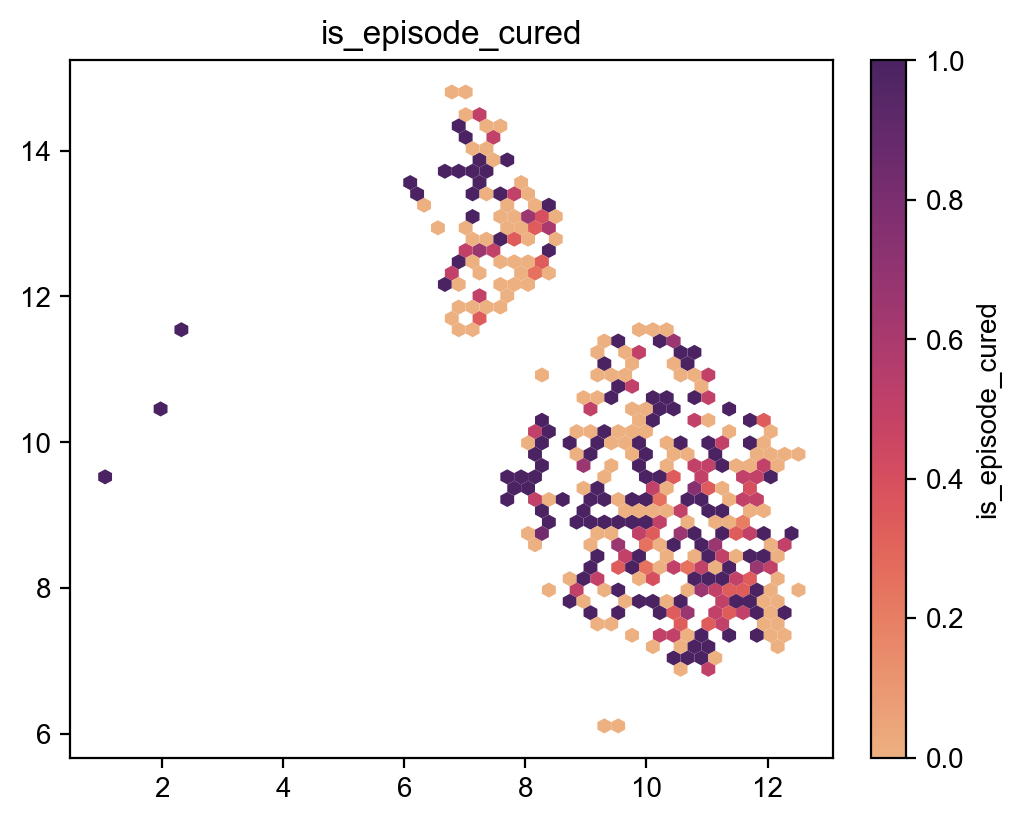

In [ ]:
plot_df['is_episode_cured_color'] = plot_df.is_episode_cured.replace({-1: np.nan})
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df.is_episode_cured_color,
    gridsize=50,
    cmap='flare',
    ec='none',
)

norm = plt.Normalize(plot_df.is_episode_cured_color.min(), plot_df.is_episode_cured_color.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
sm.set_array([])

# Remove the legend and add a colorbar
# ax.get_legend().remove()
ax.figure.colorbar(sm, ax=ax, label='is_episode_cured')

ax.set_title('is_episode_cured')

In [28]:
plot_df['ECMO_CRRT'] = 'No CRRT or ECMO'
plot_df.loc[plot_df.ECMO_flag.eq(1), 'ECMO_CRRT'] = 'ECMO'
plot_df.loc[plot_df.CRRT_flag.eq(1), 'ECMO_CRRT'] = 'CRRT'
plot_df.loc[plot_df.CRRT_flag.eq(1) & plot_df.ECMO_flag.eq(1), 'ECMO_CRRT'] = 'CRRT + ECMO'
plot_df['ECMO_CRRT'] = pd.Categorical(
    plot_df['ECMO_CRRT'],
    categories=['No CRRT or ECMO', 'CRRT', 'ECMO', 'CRRT + ECMO']
)

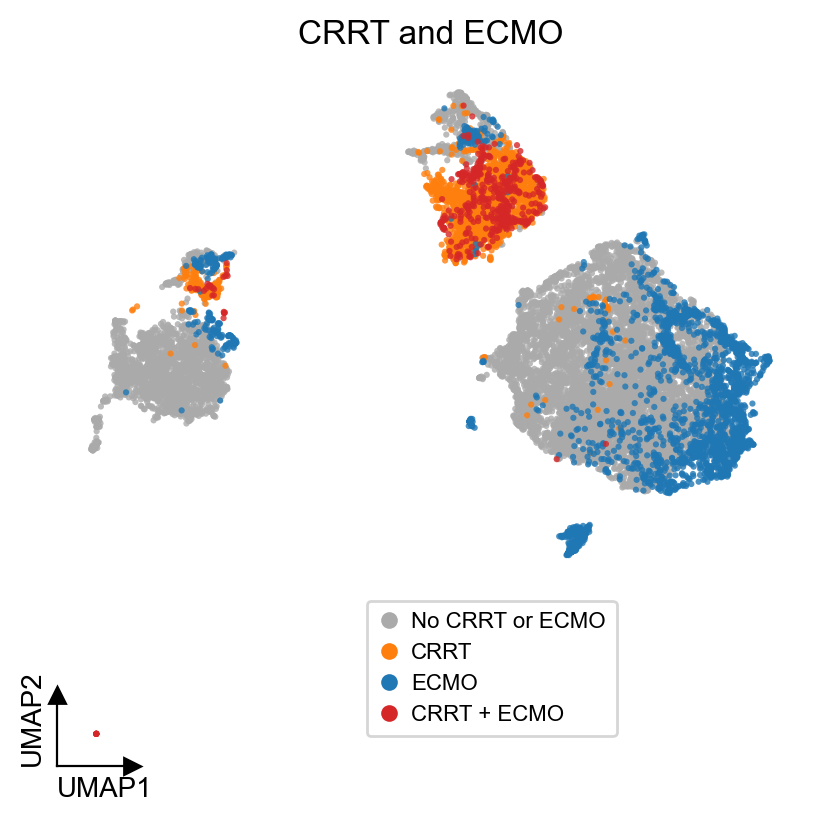

In [29]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

sns.scatterplot(
    data=plot_df.sort_values('ECMO_CRRT'),
    x='umap_1',
    y='umap_2',
    hue='ECMO_CRRT',
    palette=['#aaa', 'C1', 'C0', 'C3'],
    s=5,
    alpha=0.8,
    ec='none'
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    ncols=1,
    fontsize=8,
    loc='upper left',
    bbox_to_anchor=(0.4, 0.25),
    borderpad=0.5,
    labelspacing=0.5,
    handlelength=1,
    handletextpad=0.5,
)
for lh in ax.legend_.legend_handles:
    lh.set_alpha(1)
    lh.set_markersize(6)

ax.collections[0].set_rasterized(True)
ax.set_title('CRRT and ECMO')
fig.savefig(f'00_plots/ehrformer_emb_ecmo_crrt.pdf', dpi=300)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


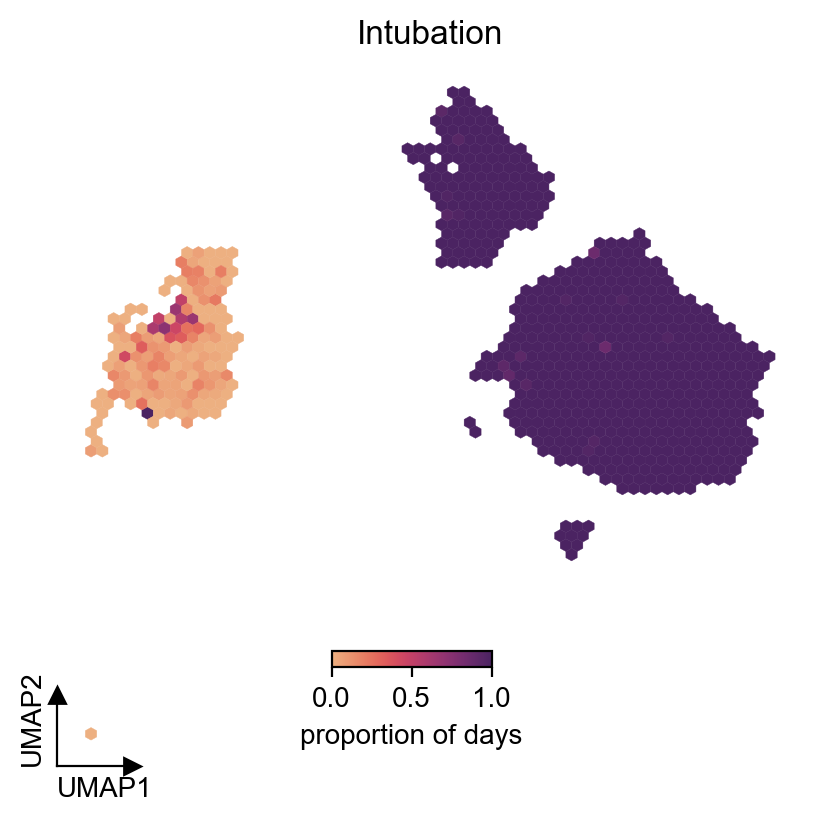

In [30]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['Intubation_flag'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='proportion of days',
    orientation='horizontal',
    ticks=[0, 0.5, 1]
)
ax.collections[0].set_rasterized(True)
ax.set_title('Intubation')
fig.savefig(f'00_plots/ehrformer_emb_intub.pdf', dpi=300)
# plt.show()

Copy logic for forward-filling pathogen groups from 00_labels to here for
`Pathogen_bacteria_detected` and `Pathogen_virus_detected` flags

In [20]:
plot_df[['Pathogen_bacteria_detected', 'BAL_performed']].value_counts(dropna=False)

Pathogen_bacteria_detected  BAL_performed
NaN                         False            13546
False                       True               888
True                        True               835
NaN                         True                18
dtype: int64

In [22]:
plot_df['Virus_detected'] = plot_df.Pathogen_virus_detected.copy()
plot_df['Bacteria_detected'] = plot_df.Pathogen_bacteria_detected.copy()

In [23]:
idx = plot_df.Episode_duration.notna() & plot_df.Episode_is_cured.eq('Cured')
for i, row in plot_df.loc[idx].iterrows():
    try:
        target_idx = plot_df.index[int(plot_df.index.get_loc(i) + row.Episode_duration)]
    except:
        continue
    target_row = plot_df.loc[target_idx]
    if (row.patient == target_row.patient
            and row.ICU_stay == target_row.ICU_stay):
        if np.isnan(target_row.Virus_detected):
            plot_df.loc[target_idx, 'Virus_detected'] = False
        if np.isnan(target_row.Bacteria_detected):
            plot_df.loc[target_idx, 'Bacteria_detected'] = False

In [30]:
def ffill_detected_flags(patient_stay_df):
    result = []
    prev_vir = np.nan
    prev_bac = np.nan
    virus_cleared = None
    for _, row in patient_stay_df.iterrows():
        if not pd.isnull(row.Virus_cleared_on):
            virus_cleared = row.Virus_cleared_on
        # Clear viruses if virus_cleared
        if virus_cleared == row.ICU_day:
            prev_vir = False
        # Current BAL has priority
        if not pd.isnull(row.Virus_detected):
            prev_vir = row.Virus_detected
        if not pd.isnull(row.Bacteria_detected):
            prev_bac = row.Bacteria_detected
        result.append([prev_vir, prev_bac])
    return pd.DataFrame(result, index=patient_stay_df.index, columns=['Virus_detected', 'Bacteria_detected'])
# here groupby resorts rows, so we cannot just assign with `.values`
# we need to match by index
ffilled_pathogens = plot_df.groupby(['patient', 'ICU_stay'], group_keys=False).apply(ffill_detected_flags)
plot_df[['Virus_detected', 'Bacteria_detected']] = ffilled_pathogens

In [41]:
plot_df.Virus_detected = plot_df.Virus_detected.astype(float)
plot_df.Bacteria_detected = plot_df.Bacteria_detected.astype(float)

In [42]:
plot_df['Virus_exclusive'] = np.clip(plot_df.Virus_detected - plot_df.Bacteria_detected, 0, 1)

In [43]:
plot_df['Bacteria_exclusive'] = np.clip(plot_df.Bacteria_detected - plot_df.Virus_detected, 0, 1)

In [44]:
plot_df.Virus_detected.value_counts(dropna=False)

0.0    9292
1.0    3961
NaN    2034
Name: Virus_detected, dtype: int64

In [45]:
plot_df.Bacteria_detected.value_counts(dropna=False)

0.0    7428
1.0    5825
NaN    2034
Name: Bacteria_detected, dtype: int64

In [46]:
plot_df.Virus_exclusive.value_counts(dropna=False)

0.0    11078
1.0     2175
NaN     2034
Name: Virus_exclusive, dtype: int64

In [47]:
plot_df.Bacteria_exclusive.value_counts(dropna=False)

0.0    9214
1.0    4039
NaN    2034
Name: Bacteria_exclusive, dtype: int64

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


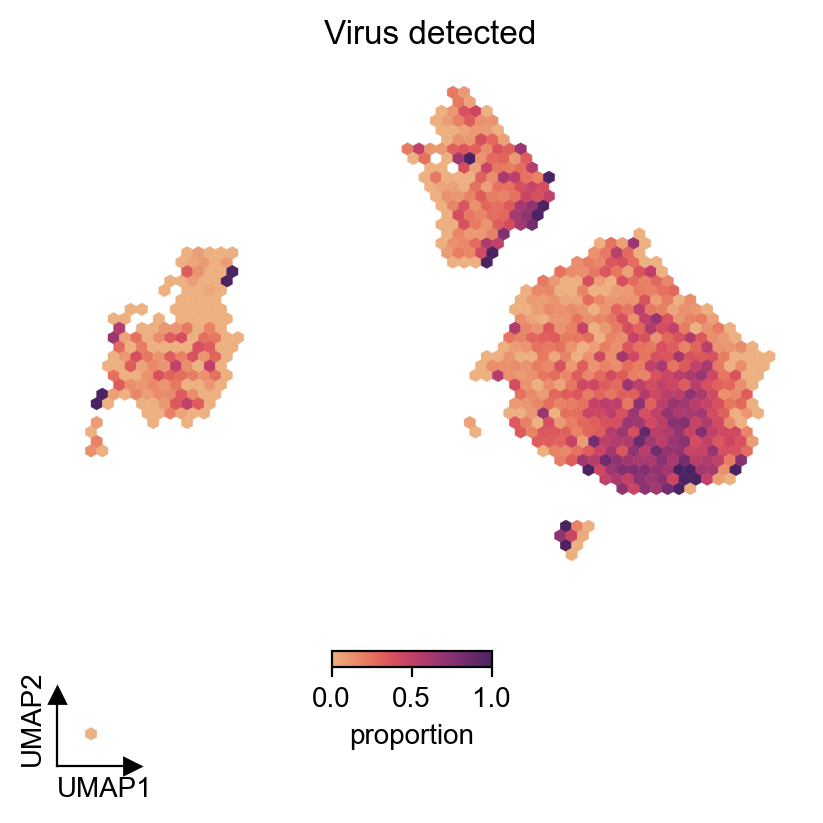

In [48]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['Virus_detected'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='proportion',
    orientation='horizontal',
    ticks=[0, 0.5, 1]
)
ax.collections[0].set_rasterized(True)
ax.set_title('Virus detected')
fig.savefig(f'00_plots/ehrformer_emb_virus_det.pdf', dpi=300)
# plt.show()

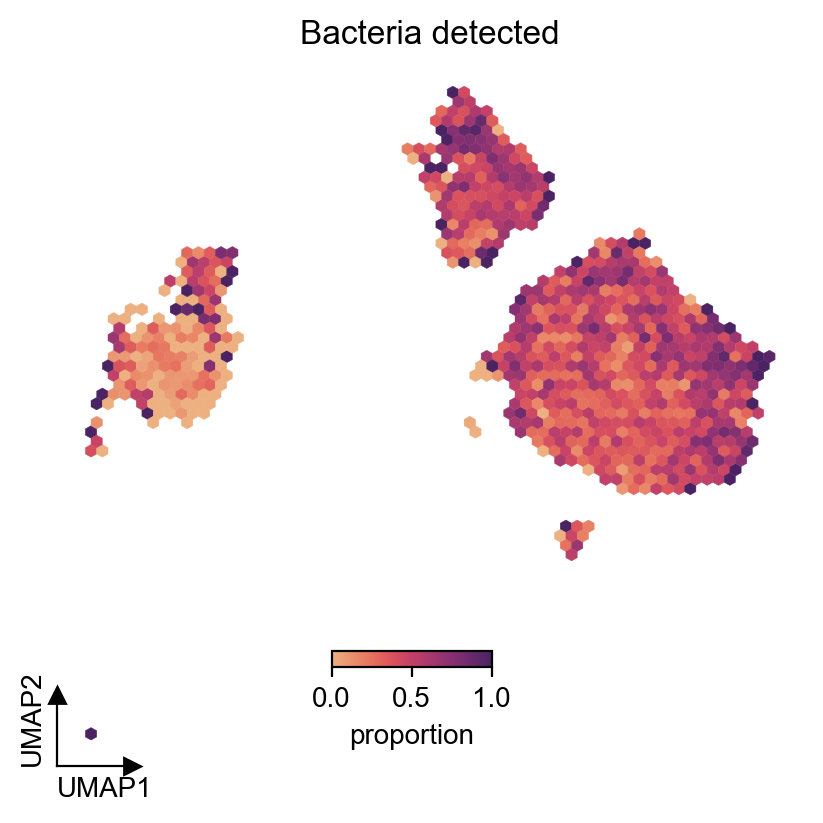

In [49]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['Bacteria_detected'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='proportion',
    orientation='horizontal',
    ticks=[0, 0.5, 1]
)
ax.collections[0].set_rasterized(True)
ax.set_title('Bacteria detected')
fig.savefig(f'00_plots/ehrformer_emb_bacteria_det.pdf', dpi=300)
# plt.show()

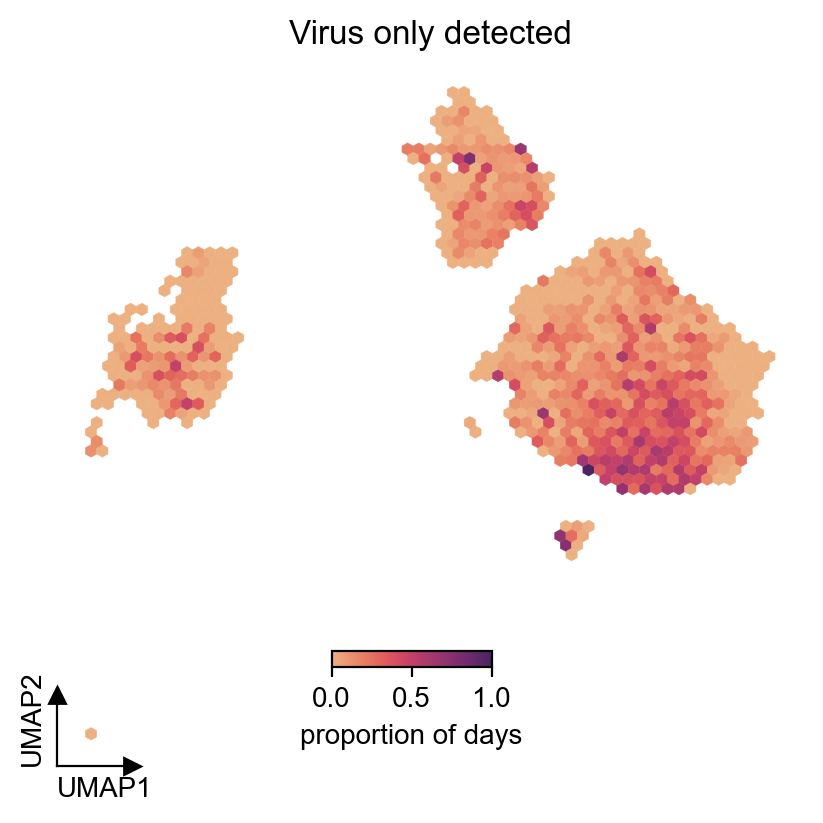

In [50]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['Virus_exclusive'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='proportion of days',
    orientation='horizontal',
    ticks=[0, 0.5, 1]
)
ax.collections[0].set_rasterized(True)
ax.set_title('Virus only detected')
fig.savefig(f'00_plots/ehrformer_emb_virus_excl.pdf', dpi=300)
# plt.show()

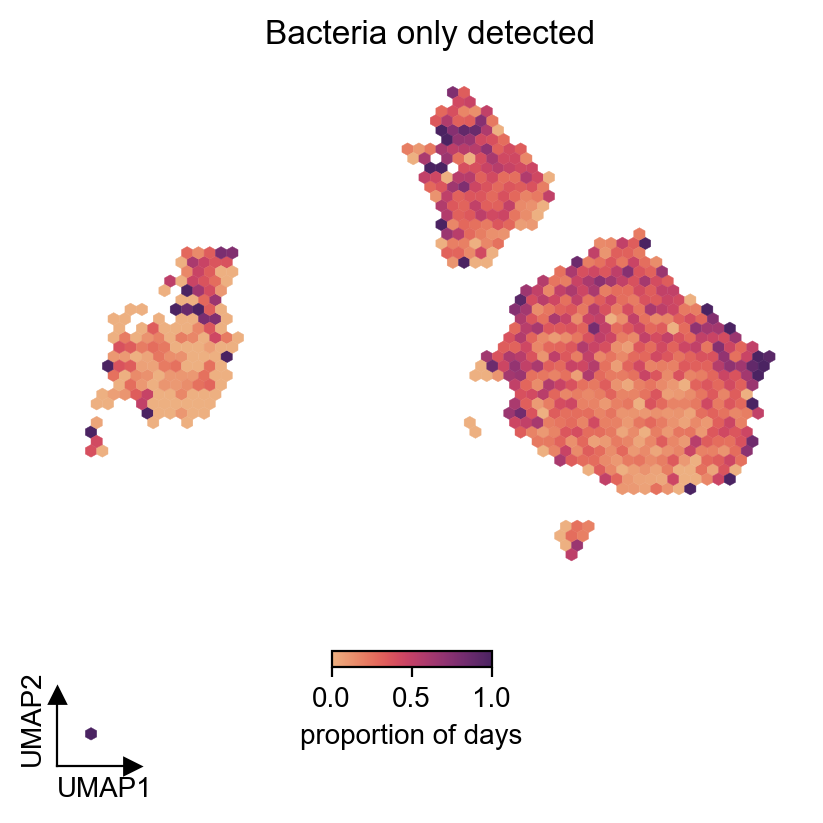

In [51]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)

ax.hexbin(
    x=plot_df.umap_1,
    y=plot_df.umap_2,
    C=plot_df['Bacteria_exclusive'],
    gridsize=60,
    cmap='flare',
    # ec='none',
    linewidths=0.15
)

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel('UMAP1', x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel('UMAP2', y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes(AXES_POS)

ax.figure.colorbar(
    sm,
    cax=cax,
    label='proportion of days',
    orientation='horizontal',
    ticks=[0, 0.5, 1]
)
ax.collections[0].set_rasterized(True)
ax.set_title('Bacteria only detected')
fig.savefig(f'00_plots/ehrformer_emb_bacteria_excl.pdf', dpi=300)
# plt.show()